In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/pr_cleaned.csv')

def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df['reviewers_parsed']  = df['reviewers'].apply(parse_list)
df['files_parsed']      = df['files_changed'].apply(parse_list)

print(f"Loaded {len(df)} PRs")
print(f"PRs with reviewers: {df['num_reviewers'].gt(0).sum()}")
print(f"Unique authors    : {df['author'].nunique()}")

Loaded 900 PRs
PRs with reviewers: 777
Unique authors    : 227


In [2]:
print("BUILDING COLLABORATION GRAPH")

G = nx.DiGraph()

for _, row in df.iterrows():
    author = row['author']
    for reviewer in row['reviewers_parsed']:
        if reviewer and reviewer != author:
            if G.has_edge(reviewer, author):
                G[reviewer][author]['weight'] += 1
            else:
                G.add_edge(reviewer, author, weight=1)

print(f" Graph built")
print(f"Nodes (developers) : {G.number_of_nodes()}")
print(f"Edges (reviews)    : {G.number_of_edges()}")
print(f"Top 5 reviewers by out-degree:")

out_degrees = sorted(G.out_degree(weight='weight'), 
                     key=lambda x: -x[1])[:5]
for dev, deg in out_degrees:
    print(f"  {dev}: {deg} reviews given")

BUILDING COLLABORATION GRAPH
 Graph built
Nodes (developers) : 297
Edges (reviews)    : 685
Top 5 reviewers by out-degree:
  copilot-pull-request-reviewer[bot]: 269 reviews given
  SergeyKanzhelev: 122 reviews given
  dmitrivMS: 107 reviews given
  liggitt: 103 reviews given
  hoxyq: 72 reviews given


In [3]:
print("BUILDING FILE OWNERSHIP MAP")

file_experts = defaultdict(lambda: defaultdict(int))

for _, row in df.iterrows():
    for f in row['files_parsed']:
        if f:
            file_experts[f][row['author']] += 1

# Stats
total_files = len(file_experts)
print(f" Unique files tracked : {total_files}")

# Show top files with most contributors
file_contributor_count = {
    f: len(experts) for f, experts in file_experts.items()
}
top_files = sorted(file_contributor_count.items(), 
                   key=lambda x: -x[1])[:5]
print(f"\nTop 5 most collaborated files:")
for f, count in top_files:
    print(f"  {f}: {count} contributors")

BUILDING FILE OWNERSHIP MAP
 Unique files tracked : 5323

Top 5 most collaborated files:
  package.json: 16 contributors
  extensions/copilot/package.json: 12 contributors
  extensions/copilot/package-lock.json: 11 contributors
  package-lock.json: 11 contributors
  pkg/features/kube_features.go: 10 contributors


In [5]:
def recommend_reviewers(pr_author, changed_files, top_n=3):
    scores = defaultdict(float)
    
    # Score 1 — collaboration history (fixed unpacking)
    if pr_author in G:
        for reviewer, target, data in G.in_edges(pr_author, data=True):
            scores[reviewer] += data.get('weight', 1) * 0.5
    
    # Score 2 — file ownership expertise
    for f in changed_files:
        for expert, count in file_experts.get(f, {}).items():
            if expert != pr_author:
                scores[expert] += count * 1.0
    
    # Score 3 — PageRank influence
    try:
        pagerank = nx.pagerank(G, weight='weight')
        for person, pr_score in pagerank.items():
            if person != pr_author:
                scores[person] += pr_score * 10
    except:
        pass
    
    scores.pop(pr_author, None)
    
    return sorted(scores.items(), key=lambda x: -x[1])[:top_n]

# Test on a sample PR
sample = df[df['num_reviewers'] > 0].iloc[0]
recs   = recommend_reviewers(
    sample['author'],
    sample['files_parsed']
)

print(f"Sample PR by     : {sample['author']}")
print(f"Actual reviewers : {sample['reviewers_parsed'][:3]}")
print(f"Recommended      : {[r[0] for r in recs]}")

Sample PR by     : Tyriar
Actual reviewers : ['anthonykim1', 'dmitrivMS']
Recommended      : ['anthonykim1', 'dmitrivMS', 'eps1lon']


In [6]:
print(" EVALUATING RECOMMENDER ")

hits   = 0
total  = 0
top1   = 0

for _, row in df.iterrows():
    actual = set(row['reviewers_parsed'])
    if not actual or row['author'] == 'unknown':
        continue
    
    recs      = recommend_reviewers(
        row['author'], row['files_parsed'])
    recommended = set([r[0] for r in recs])
    top1_rec    = recs[0][0] if recs else None
    
    if recommended & actual:
        hits += 1
    if top1_rec in actual:
        top1 += 1
    total += 1

hit_rate  = hits / total if total > 0 else 0
top1_rate = top1 / total if total > 0 else 0

print(f" Total PRs evaluated     : {total}")
print(f" Top3 Hit Rate          : {hit_rate:.1%}")
print(f" Top1 Accuracy          : {top1_rate:.1%}")
print(f"\n Reviewer recommendation accuracy: {hit_rate:.1%}")

 EVALUATING RECOMMENDER 
 Total PRs evaluated     : 777
 Top3 Hit Rate          : 80.7%
 Top1 Accuracy          : 56.0%

 Reviewer recommendation accuracy: 80.7%


 VISUALISING NETWORK 


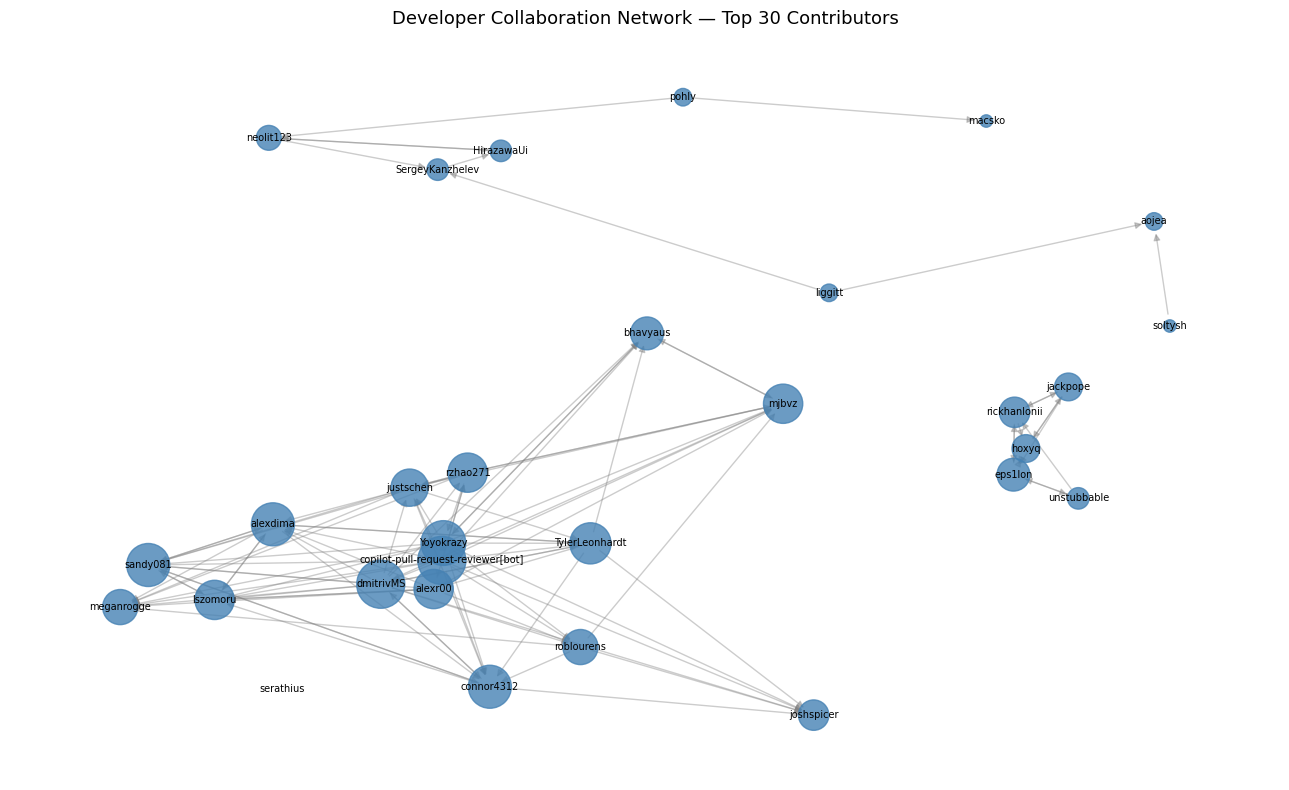

 Saved → data/collaboration_network.png


In [7]:
print(" VISUALISING NETWORK ")

# Take top 30 nodes by degree
top_nodes  = sorted(G.degree(), key=lambda x: -x[1])[:30]
subG       = G.subgraph([n[0] for n in top_nodes])

pos        = nx.spring_layout(subG, seed=42, k=0.8)
degrees    = dict(subG.degree())
node_sizes = [degrees[n] * 80 for n in subG.nodes()]

plt.figure(figsize=(13, 8))
nx.draw_networkx_nodes(subG, pos, 
    node_size=node_sizes, 
    node_color='steelblue', alpha=0.8)
nx.draw_networkx_edges(subG, pos, 
    edge_color='gray', alpha=0.4, arrows=True)
nx.draw_networkx_labels(subG, pos, font_size=7)

plt.title('Developer Collaboration Network — Top 30 Contributors', 
          fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('../data/collaboration_network.png', dpi=150)
plt.show()
print(" Saved → data/collaboration_network.png")

In [8]:
import joblib

# Convert defaultdict to regular dict for saving
file_experts_dict = {
    f: dict(experts) 
    for f, experts in file_experts.items()
}
joblib.dump(file_experts_dict, 
            '../data/processed/file_experts.pkl')

nx.write_gexf(G, '../data/processed/collaboration_graph.gexf')

print(" Saved file_experts.pkl")
print(" Saved collaboration_graph.gexf")
print(f"\n=== DAY 6 COMPLETE ===")
print(f" Collaboration graph : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f" Files tracked       : {len(file_experts_dict)}")
print(f" Top-3 hit rate      : {hit_rate:.1%}")
print(f" Top-1 accuracy      : {top1_rate:.1%}")


 Saved file_experts.pkl
 Saved collaboration_graph.gexf

=== DAY 6 COMPLETE ===
 Collaboration graph : 297 nodes, 685 edges
 Files tracked       : 5323
 Top-3 hit rate      : 80.7%
 Top-1 accuracy      : 56.0%
